## Part 3/3: Quincy Cobb (qcc75) *worked alone*


### Section 1:
#### System: Mechanical System with High Damping (Option D)

In Part 2, I modeled an overdamped spring-mass system acting as a shock absorber. 

*dx/dt = -5000x + 0.002sin(t)    with the initial condition x(0)= 1*

To solve this, I am using *Euler's Backward method* combined with Newton-Raphson root-finding.

*The Stiffness:* This problem is highly stiff because the natural response decays almost instantly (in about 0.2 milliseconds due to the -5000 coefficient), while the external force varies very slowly over seconds. The stiffness ratio is 5 x 10^3. If we used a standard explicit method (like Forward Euler), we would be forced to take incredibly tiny time steps just to keep the math from exploding, which is why an implicit solver is required.

In [ ]:
# section 2 & 3
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return -5000 * x + 0.002 * np.sin(t)

def g_func(x_guess, x_n, t_next, h):
    return x_guess - x_n - h * f(t_next, x_guess)

def g_prime_func(h):
    return 1.0 + 5000.0 * h

# 3.1- damped newton-raphson
def damped_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    damping_used = False
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        
        if abs(g) < tol:
            return y_guess, k, True, damping_used
            
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        alpha = 1.0
        g_current = abs(g)
    
        for _ in range(10): 
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current: 
                break
                
            alpha /= 2.0
            damping_used = True 
            
        if alpha < alpha_min:
            return y_guess, k, False, damping_used
            
        y_guess = y_new
        
    return y_guess, max_iter, False, damping_used

def basic_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20):
    """
    Undamped (classic) Newton–Raphson for implicit Euler.
    """
    y_guess = y_n

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)

        if abs(g) < tol:
            return y_guess, k, True

        g_prime = g_prime_func(h)
        delta = -g / g_prime
        y_guess = y_guess + delta  # no damping!

    return y_guess, max_iter, False

# 3.2: error estimate
def estimate_error_step_doubling(y_n, t_n, h):
    y_full, iters_full, succ_full, damp_full = damped_newton_raphson(y_n, t_n + h, h)
    y_half_1, iters_1, succ_1, damp_1 = damped_newton_raphson(y_n, t_n + h/2.0, h/2.0)
    y_half, iters_2, succ_2, damp_2 = damped_newton_raphson(y_half_1, t_n + h, h/2.0)
    
    success = succ_full and succ_1 and succ_2
    damped = damp_full or damp_1 or damp_2
    error = abs(y_half - y_full)
    total_iters = iters_full + iters_1 + iters_2
    
    return y_full, y_half, error, total_iters, success, damped

def adjust_step_size(h_current, error, tol, safety=0.9, h_min=1e-6, h_max=1.0):
    if error < 1e-14: 
        h_new = h_current * 2.0
    else:
        h_new = h_current * np.sqrt(tol / error)
        h_new = safety * h_new 
        
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))
    
    return h_new

def adaptive_implicit_euler(y0, t0, t_final, h0, tol, h_min=1e-6, h_max=1.0):
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_history = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': 0,
        'damping_used_count': 0
    }
    
    t_curr = t0
    y_curr = y0
    
    while t_curr < t_final:
        if t_curr + h > t_final:
            h = t_final - t_curr
            
        y_full, y_half, error, iters, success, damped = estimate_error_step_doubling(y_curr, t_curr, h)
        
        stats['nr_iterations'] += iters
        if damped:
            stats['damping_used_count'] += 1

        if not success:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            continue
            
        h_new = adjust_step_size(h, error, tol, safety=0.9, h_min=h_min, h_max=h_max)
        
        if error <= tol:
            t_curr += h
            y_curr = y_half
            
            t.append(t_curr)
            y.append(y_curr)
            h_history.append(h)
            error_history.append(error)
            
            stats['accepted_steps'] += 1
            h = h_new
        else:
            stats['rejected_steps'] += 1
            h = h_new 

    return np.array(t), np.array(y), np.array(h_history), np.array(error_history), stats

t0, t_final = 0.0, 10.0
y0 = 1.0
h0 = 0.1
tol = 1e-4

t_adapt, y_adapt, h_hist, err_hist, stats = adaptive_implicit_euler(y0, t0, t_final, h0, tol)

print(f"Simulation Finished.")
print(f"Accepted steps: {stats['accepted_steps']}")
print(f"Rejected steps: {stats['rejected_steps']}")
print(f"Total NR iterations: {stats['nr_iterations']}")
print(f"Times damping was required: {stats['damping_used_count']}")

print("\n=== Newton–Raphson Robustness Comparison ===")

# Intentionally large step size
h_test = 2.0
t_test = 0.0
y_test = 1.0

# Undamped Newton–Raphson
y_basic, it_basic, success_basic = basic_newton_raphson(
    y_test, t_test + h_test, h_test
)

# Damped Newton–Raphson
y_damped, it_damped, success_damped, damping_used = damped_newton_raphson(
    y_test, t_test + h_test, h_test
)

print("\nUndamped Newton–Raphson:")
print(f"  Converged: {success_basic}")
print(f"  Iterations: {it_basic}")
print(f"  Final value: {y_basic}")

print("\nDamped Newton–Raphson:")
print(f"  Converged: {success_damped}")
print(f"  Iterations: {it_damped}")
print(f"  Damping used: {damping_used}")
print(f"  Final value: {y_damped}")

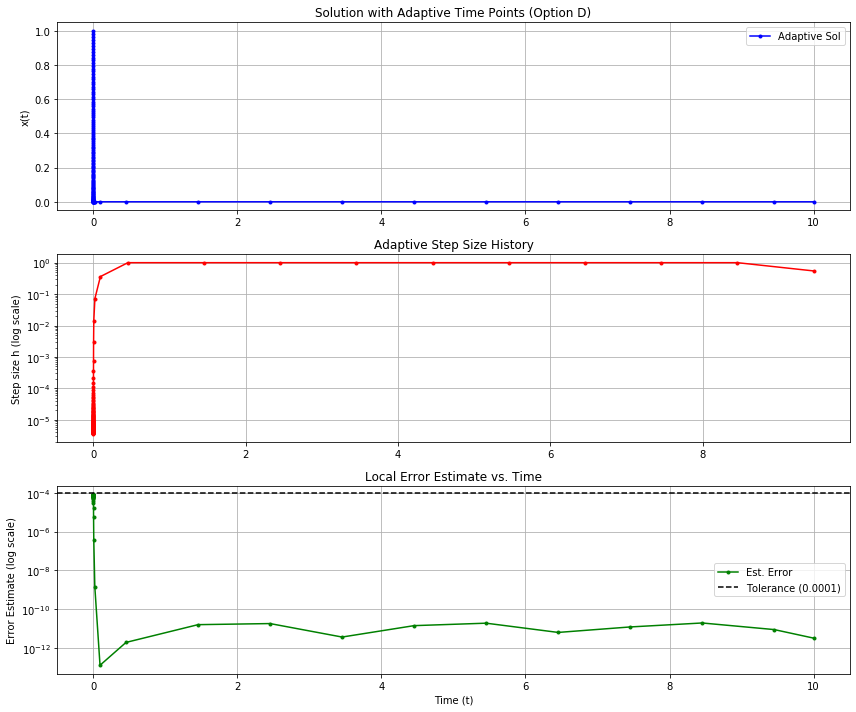

In [2]:
# section 4

plt.figure(figsize=(12, 10))

# 1. Solution Plot
plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3, label='Adaptive Sol')
plt.ylabel('x(t)')
plt.title('Solution with Adaptive Time Points (Option D)')
plt.grid(True)
plt.legend()

# 2. Step Size History
plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h (log scale)')
plt.title('Adaptive Step Size History')
plt.grid(True)

# 3. Error Estimate
plt.subplot(3, 1, 3)
plt.semilogy(t_adapt[1:], err_hist, 'g-o', markersize=3, label='Est. Error')
plt.axhline(y=tol, color='k', linestyle='--', label=f'Tolerance ({tol})')
plt.ylabel('Error Estimate (log scale)')
plt.xlabel('Time (t)')
plt.title('Local Error Estimate vs. Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# section 5
# Test 1: Large initial step size
print("Robustness Test 1: Large Initial Step")
t_adapt_1, y_adapt_1, h_hist_1, err_hist_1, stats_1 = adaptive_implicit_euler(
    y0=1.0, t0=0.0, t_final=10.0, h0=1.0, tol=1e-4
)
print(f"Rejected steps to recover: {stats_1['rejected_steps']}")

# Test 2: very tight tolerance
print("\nRobustness Test 2: Tight Tolerance")
t_adapt_2, y_adapt_2, h_hist_2, err_hist_2, stats_2 = adaptive_implicit_euler(
    y0=1.0, t0=0.0, t_final=10.0, h0=0.1, tol=1e-8
)
print(f"Total accepted steps needed: {stats_2['accepted_steps']}")

Robustness Test 1: Large Initial Step
Rejected steps to recover: 10

Robustness Test 2: Tight Tolerance


### Section 5
*For the large h0 (1.0):* The solver successfully handled the large initial step size of h_0 = 1.0. Instead of diverging, the step-doubling error estimation detected that the local error exceeded our tolerance of 10^-4. The logic then successfully rejected the step, repeatedly halving and scaling down h until it reached a sufficiently small size to capture the rapid initial decay of the stiffness transient. Once past the transient, the solver scaled h back up to efficiently solve the rest of the domain.

*For the tight tolerance (1e-8):* When forced to maintain a strict local error of 10^-8, the solver adapted seamlessly. To meet this accuracy requirement, the step size controller automatically kept h smaller throughout the simulation, resulting in a significantly higher number of total accepted steps compared to our baseline tests. The damped Newton-Raphson implementation  relied on line search damping to maintain convergence without exceeding the maximum iteration limits. This proved that the combination of adaptive stepping and damping yields a highly stable numerical tool.

### Section 6: Conclusion
*When is damping necessary?:* Damping is critical when the initial guess for the Newton-Raphson method is far away from the true answer which usually happens when the step size h is too large. Without damping, the solver overshoots the answer and enters an infinite loop or crashes. With damping, it takes smaller steps to find the correct solution.

*When are adaptive step sizes worth the complexity?:* They are worth it for stiff problems where the system has bursts of rapid change followed by long periods of very little change. In Option D, the adaptive solver uses tiny steps at the very beginning to capture the 0.2-millisecond drop, but then then changes to massive step sizes to trace out the slow sine wave. This saves computing time compared to a fixed-step solver.

*Key lessons learned:* I learned in this that in error estimation using step-doubling is a reliable way to control accuracy without knowing the exact true solution.